This notebook is only to see the catboost regressor of the RNAseq z-score combat (withour ridge)

In [60]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import feature_selection as fs
import pickle
from convert_ensembl_2_symbol import convert_to_symbol, filter_nameless_genes

In [61]:
fit=False
testing_size='07'
testing_size_f=0.07

In [62]:
orignal_dataset = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_z_score_adjustedCombat.csv")
len(orignal_dataset)

270

In [63]:
eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_train.csv")
len(eigth_bins)

162

In [64]:
seq_metadata_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/All_rna_samples_metadata_edit.csv"
seq_metadata = pd.read_csv(seq_metadata_path)
seq_metadata
sarcopenia_df = seq_metadata[seq_metadata['Status']=='Sarcopenia']

In [65]:
no_sarcopenia_df = eigth_bins[~eigth_bins['Sample'].isin(sarcopenia_df['Sample'])]
no_sarcopenia_df.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Experiment,Age,Sample
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,GSE157585,71.0,SRR12604093
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,GSE129643,58.0,SRR8882184
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,GSE157585,71.0,SRR12604092
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,GSE164471,42.0,SRR13388738
5,-0.020626,-0.022261,-0.004969,-0.022744,-0.021211,-0.022646,-0.021416,-0.021615,-0.021888,-0.022172,...,-0.022329,-0.022295,-0.021260,-0.022285,-0.022348,-0.021014,-0.022187,GSE157585,24.0,SRR12604226


In [6]:
len(no_sarcopenia_df)

147

In [66]:
seq_y_train_cat_a=no_sarcopenia_df["Age"]
seq_y_train_a = pd.Series(seq_y_train_cat_a)

dataset = no_sarcopenia_df.copy()
dataset["Age"]=seq_y_train_a
dataset.drop(columns=["Sample","Experiment"], inplace=True)
dataset.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,71.0
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,58.0
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71.0
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,42.0
5,-0.020626,-0.022261,-0.004969,-0.022744,-0.021211,-0.022646,-0.021416,-0.021615,-0.021888,-0.022172,...,-0.022341,-0.022168,-0.022329,-0.022295,-0.021260,-0.022285,-0.022348,-0.021014,-0.022187,24.0


In [67]:
### ALl the aumentation
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = m.divide_test_train_dataset(no_sarcopenia_df, test_size=0.4)
seq_age_ranges = divide.get_age_distribution(seq_y_train, age_ranges=[18, 25, 35, 45,70,72,  100])
seq_categories = [18, 25, 35, 45, 70, 72, 90]
seq_y_train_cat = seq_y_train.apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
dataset = pd.DataFrame(seq_X_train)
dataset["Age"] = seq_y_train_cat

result = divide.get_feature_SMOTE(dataset, is_categorical=True,k=4)
seq_X_train_cat_a = pd.DataFrame(result[0])
seq_y_train_cat_a = result[1]
noise = np.random.normal(0.01, 0.01, seq_X_train_cat_a.shape)  # Generate random noise with mean 0 and standard deviation 1

seq_y_train_a = pd.Series(seq_y_train_cat_a).str.split('-')
seq_y_train_a = seq_y_train_a.apply(lambda x: (int(x[0]) + int(x[1])) / 2)

y_noise = np.random.normal(0, 2, seq_y_train_a.shape)
seq_y_train_a = seq_y_train_a + y_noise
seq_y_train_a = seq_y_train_a.round(0)


Class distribution before SMOTE: Counter({'70-72': 27, '25-35': 18, '18-25': 15, '45-70': 12, '72-100': 11, '35-45': 5})
Class distribution after SMOTE: Counter({'25-35': 27, '70-72': 27, '18-25': 27, '45-70': 27, '72-100': 27, '35-45': 27})


In [ ]:
class optimize:
    def __init__(self,train_data, n_trials=50):
        X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(train_data, test_size=testing_size_f)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.n_trials = n_trials
    def optimize(self):
        study = optuna.create_study(direction='minimize')  # Maximize accuracy
        study.optimize(self.objective, n_trials=self.n_trials) 
    def objective(self, trial):
        # Define hyperparameters to optimize
        params = {
            'iterations': trial.suggest_int('iterations', 50, 1000),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
            'depth': trial.suggest_int('depth', 2, 5),
            'random_state': 42,  # Fixed random state
            'verbose': 0,  # Fixed verbosity
            'od_type': 'Iter',  # Early stopping type
            'od_wait': 5,  # Early stopping patience
            #'eval_metric': 'RMSE'  # Metric to optimize

        }
        params = {
        'iterations': trial.suggest_int('iterations', 50, 100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
        'depth': trial.suggest_int('depth', 2, 5),  # Modify depth range to match the original
        'verbose': 0,  # Fixed verbosity
        'od_type': 'Iter',  # Early stopping type
        'od_wait': 5,  # Early stopping patience
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.0, 10.0),  # L2 regularization coefficient
        #'sampling_frequency': trial.suggest_categorical('sampling_frequency', ['PerTree', 'PerTreeLevel', 'PerTreeNode']),  # Frequency of sampling
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),  # Random strength
        #'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),  # Tree growth policy
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),  # Minimum number of samples in leaf
        #'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),  # Type of boosting
        'score_function': trial.suggest_categorical('score_function', ['Cosine', 'L2']),  # Metric to use
        'penalties_coefficient': trial.suggest_float('penalties_coefficient', 0.0, 10.0),  # Penalty coefficient
        'model_shrink_rate': trial.suggest_float('model_shrink_rate', 0.0, 1.0),  # Model shrink rate
        #'model_shrink_mode': trial.suggest_categorical('model_shrink_mode', ['Constant', 'ShrinkToBest', 'ShrinkToRandom']),  # Model shrink mode
        'eval_metric': 'RMSE'  # Metric to optimize
    }

        # Initialize classifier with the suggested hyperparameters
        regressor = CatBoostRegressor(**params)

        # Fit the model
        regressor.fit(self.X_train, self.y_train, eval_set=(self.X_test, self.y_test), use_best_model=True)
        # Make predictions
        y_pred = regressor.predict(self.X_test)
        # Calculate rmse
        rmse = mean_squared_error(self.y_test, y_pred, squared=False)
        return rmse


In [ ]:

if fit:
    optimize = optimize(train_data = dataset, n_trials=20)
    params = optimize.optimize()
    params

In [68]:
# [I 2024-09-25 21:18:19,700] Trial 6 finished with value: 4.733188762255442 and parameters: 
params = {'iterations': 556, 'learning_rate': 0.008352826387919279, 'depth': 3, 'l2_leaf_reg': 8.625993928282805, 'random_strength': 5.518222301454832, 'min_data_in_leaf': 37, 'score_function': 'L2', 'penalties_coefficient': 0.9978892027428243, 'model_shrink_rate': 0.03029125396360066}
#. Best is trial 6 with value: 4.733188762255442.


In [69]:
dataset = pd.DataFrame(seq_X_train_cat_a)
dataset.columns = seq_X_train_cat_a.columns
dataset["Age"] = seq_y_train_a


/tmp/ipykernel_26462/2280029578.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset["Age"] = seq_y_train_a


In [ ]:
#params = {'iterations': 2000, 'learning_rate': 0.0057754728847108075, 'depth': 4, 'l2_leaf_reg': 1.4995313057538833, 'random_strength': 3.6144926272336773, 'min_data_in_leaf': 33, 'score_function': 'Cosine', 'penalties_coefficient': 7.492437722110218, 'model_shrink_rate': 0.0036095159058368662}

In [ ]:
#fit=True

In [71]:
X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=testing_size_f)
#random_strength

# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(**params) 

# Fit the model
if fit:
    seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=False)

In [72]:
if fit:
    # Specify the file path where you want to save the pickle file
    file_path = f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_7_SMOTE_seq_regressor_NoSarcopenia_{testing_size}.pkl'

    # Save the seq_regressor variable in the pickle file
    with open(file_path, 'wb') as f:
        pickle.dump(seq_regressor, f)
else:

    # Specify the file path where the pickle file is located
    file_path = f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_7_SMOTE_seq_regressor_NoSarcopenia_{testing_size}.pkl'

    # Load the seq_regressor object from the pickle file
    with open(file_path, 'rb') as f:
        seq_regressor = pickle.load(f)

    # Now you can use the seq_regressor object in your code


In [73]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse

22.355723847645972

In [74]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R2
r2 = r2_score(y_test, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 22.355723847645972
RMSE: 4.728183990460393
MAE: 3.9999257883583748
R2: 0.9591194047511522


In [75]:
age_ranges_list=[18, 26, 35, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(y_test, age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 1},
 {'label': '26-35', 'range': (26, 35), 'count': 2},
 {'label': '35-65', 'range': (35, 65), 'count': 4},
 {'label': '65-71', 'range': (65, 71), 'count': 0},
 {'label': '71-72', 'range': (71, 72), 'count': 2},
 {'label': '72-95', 'range': (72, 95), 'count': 2}]

In [76]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[1, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0, 0, 0],
       [0, 0, 4, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 2, 0, 0, 0],
       [0, 0, 0, 0, 0, 2, 0],
       [1, 0, 0, 0, 0, 0, 0]])

In [77]:
seq_auc=accuracy_score(c_y_test.round(0), c_y_pred.round(0))
seq_auc

0.6666666666666666

In [78]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.6340296684025701

In [79]:
y_test

93     23.0
40     17.0
76     30.0
16     71.0
29     57.0
106    30.0
139    57.0
146    89.0
149    86.0
71     71.0
136    58.0
37     38.0
Name: Age, dtype: float64

In [80]:
seq_results

,Actual,Predicted
93,23.0,21.886390
40,17.0,24.767142
76,30.0,30.027662
16,71.0,66.471707
29,57.0,51.451990
106,30.0,25.595362
139,57.0,55.646389
146,89.0,80.153614
149,86.0,81.133214
71,71.0,68.266139


In [23]:
seq_results.to_csv(f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_results_testset_NonSarcopenia_{testing_size}.csv")

/tmp/ipykernel_20485/528406118.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


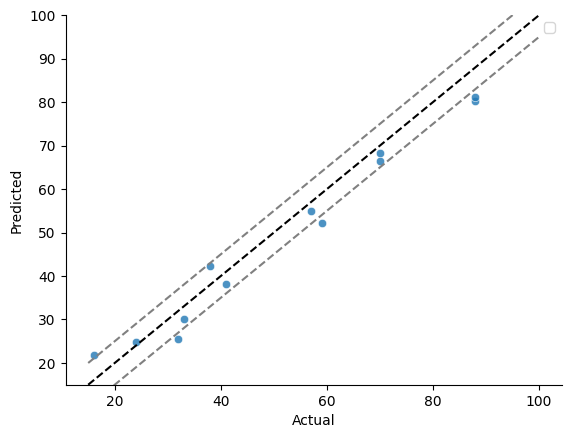

In [24]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_test_set_scatterplot_{testing_size}.png')
plt.show()

In [81]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[1, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0, 0, 0],
       [0, 0, 4, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 2, 0, 0, 0],
       [0, 0, 0, 0, 0, 2, 0],
       [1, 0, 0, 0, 0, 0, 0]])

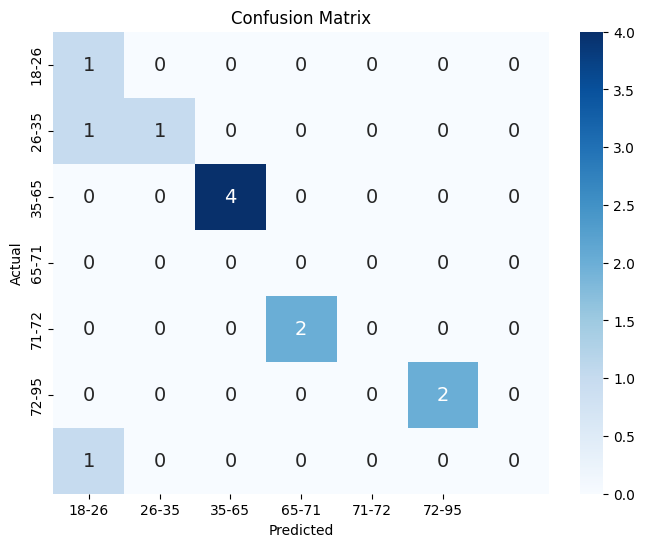

In [82]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_test_set_confusion_matrix_NonSarcopenia_{testing_size}.png')
plt.show()

In [83]:
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_z_score_Test_set.csv")
eigth_bins_test.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Status,Experiment,Age.1,Sample,Sex
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.024472,-0.024526,-0.023199,-0.024432,24.0,Healthy,GSE157585,24.0,SRR12604218,NaN
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.025252,-0.025311,-0.024447,-0.025087,18.0,Healthy,GSE167186,18.0,SRR13759023,NaN
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.029934,-0.029985,-0.022886,-0.029776,23.0,Healthy,GSE167186,23.0,SRR13759025,NaN
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.028774,-0.028772,-0.027571,-0.028812,26.4,untrained,GSE60590,26.4,SRR1555206,female
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.026722,-0.026784,-0.025465,-0.026577,71.0,Healthy,GSE157585,71.0,SRR12604184,NaN


In [84]:
age_ranges_list=[18, 26, 35, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(eigth_bins_test["Age"], age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-65', 'range': (35, 65), 'count': 17},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [85]:
X_test_untoached = eigth_bins_test.drop(columns=["Age"])
X_test_untoached.drop(columns=["Experiment", "Sample", "Age.1", "Status", "Sex"], inplace=True)
y_test_untoached = eigth_bins_test["Age"]
seq_z_test = eigth_bins_test["Experiment"]

In [86]:
X_test_untoached.columns

Index(['ENSG00000000003.14', 'ENSG00000000005.5', 'ENSG00000000419.12',
       'ENSG00000000457.13', 'ENSG00000000460.16', 'ENSG00000000938.12',
       'ENSG00000000971.15', 'ENSG00000001036.13', 'ENSG00000001084.11',
       'ENSG00000001167.14',
       ...
       'ENSG00000285458.1', 'ENSG00000285470.1', 'ENSG00000285471.1',
       'ENSG00000285472.1', 'ENSG00000285476.1', 'ENSG00000285480.1',
       'ENSG00000285491.1', 'ENSG00000285505.1', 'ENSG00000285508.1',
       'ENSG00000285509.1'],
      dtype='object', length=34505)

In [87]:
seq_z_test = pd.DataFrame(seq_z_test)
seq_z_test.columns = ["Experiment"]

In [96]:
# Make predictions
y_pred = seq_regressor.predict(X_test_untoached)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test_untoached, y_pred)
seq_results = pd.DataFrame({'Actual': y_test_untoached, 'Predicted': y_pred})
seq_mse

42.73507091475209

In [97]:
seq_results.to_csv(f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_results_untoached_NonSarcopenia_{testing_size}.csv")


/tmp/ipykernel_20485/1741262349.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


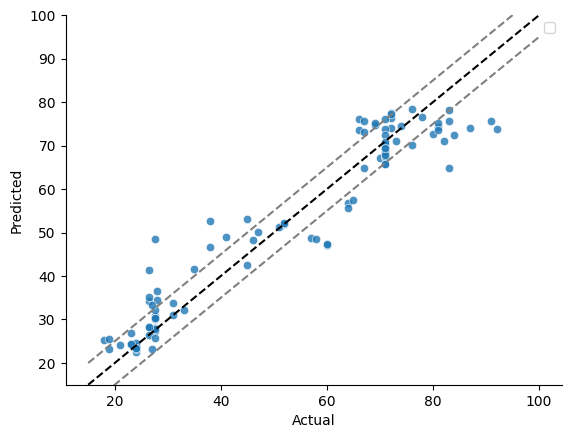

In [33]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_untouched_set_scatterplot_{testing_size}.png')
plt.show()

In [34]:
from importlib import reload
reload(m)

<module 'model' from '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/model.py'>

     Actual  Predicted Experiment
0      24.0  23.977013  GSE157585
1      18.0  25.231372  GSE167186
2      23.0  24.439945  GSE167186
3      26.4  34.359675   GSE60590
4      71.0  67.786434  GSE157585
..      ...        ...        ...
103    71.0  69.333342  GSE157585
104    23.0  24.399674  GSE167186
105    72.0  77.367391  GSE164471
106    71.0  65.738181  GSE157585
107    71.0  76.068905  GSE167186

[108 rows x 3 columns]


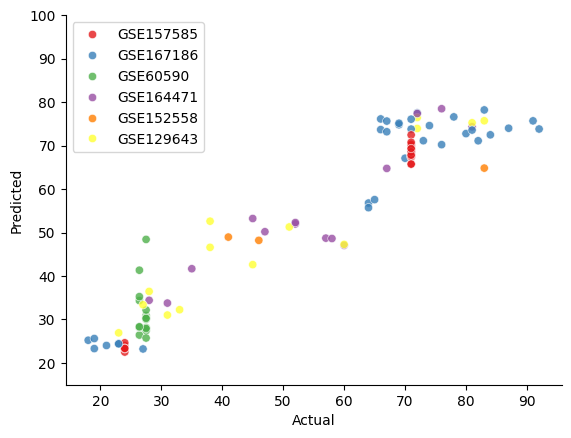

In [35]:
m.output_directory = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/Catboost"
m.plot_results(results=seq_results, labels=seq_z_test, save=True, save_output=f"catboost_regression_smote_untoached_nonSarcopenia_{testing_size}.png")

In [10]:
c_y_test = pd.Series(y_test_untoached).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[12,  1,  0,  0,  0,  0],
       [ 2, 17,  4,  0,  0,  0],
       [ 0,  0, 17,  0,  0,  0],
       [ 0,  0,  2,  1,  0,  6],
       [ 0,  0,  0, 22,  0,  3],
       [ 0,  0,  1,  1,  2, 17]])

In [11]:
acu = accuracy_score(c_y_test, c_y_pred)
acu

0.5925925925925926

In [12]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.5409554310521076

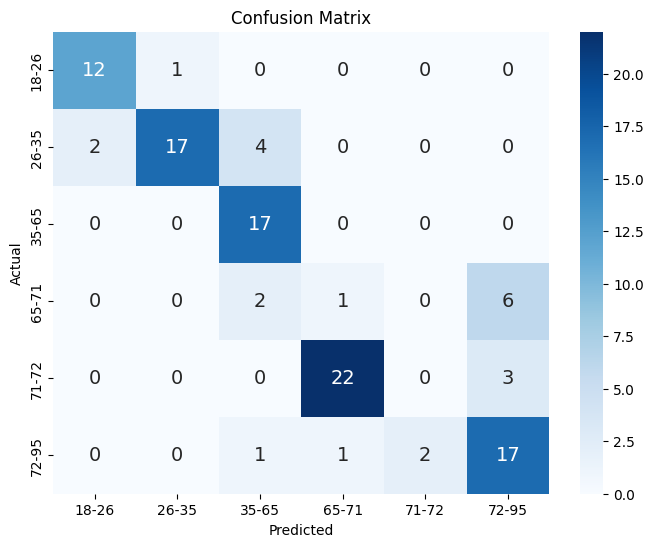

In [39]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(f"RNAseq_catboost_untoached_test_set_confusion_matrix_NonSarcopenia_{testing_size}.png")
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test_untoached, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test_untoached, y_pred)

# Calculate R2
r2 = r2_score(y_test_untoached, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 42.73507091475209
RMSE: 6.537206659939097
MAE: 4.884023334031382
R2: 0.9146420137637553


In [ ]:
#explainer = shap.Explainer(seq_regressor, X_test)
#shap_values = explainer.shap_values(X_test, check_additivity=False)
#importance = seq_regressor.get_feature_importance()
#feature_imporance_df = pd.DataFrame(importance, index=X_test.columns, columns=["importance"])
#feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
#feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
#feature_imporance_df

In [14]:
explainer = shap.Explainer(seq_regressor)
explainer.expected_value

array([4.92697302])

In [16]:
shap_values = explainer(X_test_untoached, check_additivity=False)
with open('shap_values_catboost_nonSarcopenia.pkl', 'wb') as f:
    pickle.dump(shap_values, f)


In [17]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test_untoached.columns)

# Save the DataFrame to a CSV file
shap_df.to_csv("shap_values_by_gene_Catboost_40_extended_nonSarcopenia.csv", index=False)
shap_df

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285458.1,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=X_test_untoached.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
feature_imporance_df

,importance
ENSG00000035664.11,36.720451
ENSG00000177606.6,6.313563
ENSG00000156298.12,5.832450
ENSG00000103353.15,4.669174
ENSG00000262855.1,3.735223
...,...
ENSG00000085871.8,0.000396
ENSG00000072080.10,0.000273
ENSG00000161638.10,0.000246
ENSG00000171819.4,0.000218


In [22]:
feature_imporance_path = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_7b_feature_importance_nonSarcopenia_{testing_size}.csv"
feature_imporance_df.to_csv(feature_imporance_path)

In [37]:
feature_imporance_df=pd.read_csv(f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_7b_feature_importance_nonSarcopenia_{testing_size}.csv")
feature_imporance_df

,Unnamed: 0,importance
0,ENSG00000035664.11,36.720451
1,ENSG00000177606.6,6.313563
2,ENSG00000156298.12,5.832450
3,ENSG00000103353.15,4.669174
4,ENSG00000262855.1,3.735223
...,...,...
417,ENSG00000085871.8,0.000396
418,ENSG00000072080.10,0.000273
419,ENSG00000161638.10,0.000246
420,ENSG00000171819.4,0.000218


In [ ]:
ensebl_names = X_test_untoached.columns
with open('annot.pkl', 'rb') as f:
    annot = pickle.load(f)
ensebl_names = filter_nameless_genes(ensebl_names, annot)
symbol_names = convert_to_symbol(ensebl_names, annot)
ensebl_names = pd.Series(ensebl_names)
symbol_names = pd.Series(symbol_names)
symbol_names = symbol_names.fillna(ensebl_names)




In [28]:
# prompt: take the X_test_data columns, if the value of .split(".")[0] is in ensebl_names, get the same index on ensebl_names but in symbol_names

# Assuming 'ensebl_names' and 'symbol_names' are lists of the same length
# and that the indices in the lists correspond correctly.

# Create a mapping from Ensembl IDs to gene symbols
ensembl_to_symbol = dict(zip(ensebl_names, symbol_names))
def convert_name(ensembl_to_symbol, X_test_data):
    # if symbol_name is nan or variant, replace with the same ensebl_name
    for key, value in ensembl_to_symbol.items():
        if pd.isna(value) or value =="nan" or value is None:
            ensembl_to_symbol[key] = key
    #if X_test_data.colum is not in ensembl_to_symbol, add it with value the same as the key
    for col in X_test_data.columns:
        if col not in ensembl_to_symbol:
            ensembl_to_symbol[col] = col
    # Initialize an empty list to store the gene symbols for X_test_data columns
    selected_symbols = []


    # Iterate over columns in X_test_data
    for ensembl_id in X_test_data.columns:
        if ensembl_id in ensembl_to_symbol:
            selected_symbols.append(ensembl_to_symbol[ensembl_id])
        else:
            # Handle cases where the Ensembl ID is not found in the mapping.
            # For example, append the original column name or a placeholder
            selected_symbols.append(ensembl_id) # Or selected_symbols.append("Not Found")
    return selected_symbols
# Now 'selected_symbols' contains the corresponding gene symbols for the columns
# in X_test_data, or the original column name if the ensembl ID was not found.

In [38]:
feature_imporance_df['Unnamed: 0'] = feature_imporance_df['Unnamed: 0'].map(ensembl_to_symbol)
feature_imporance_df.columns=["Symbol", "importance"]
feature_imporance_df

,Symbol,importance
0,DAPK2,36.720451
1,JUN,6.313563
2,TSPAN7,5.832450
3,UBFD1,4.669174
4,ENSG00000262855.1,3.735223
...,...,...
417,MGST2,0.000396
418,SPP2,0.000273
419,ITGA5,0.000246
420,ANGPTL7,0.000218


In [ ]:
feature_imporance_df.index=feature_imporance_df['Symbol']


In [41]:
feature_imporance_df.drop(columns=['Symbol'], inplace=True)
feature_imporance_df

,importance
Symbol,
DAPK2,36.720451
JUN,6.313563
TSPAN7,5.832450
UBFD1,4.669174
ENSG00000262855.1,3.735223
...,...
MGST2,0.000396
SPP2,0.000273
ITGA5,0.000246


In [42]:
feature_imporance_path = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_7b_feature_importance_nonSarcopenia_symbols_{testing_size}.csv"
feature_imporance_df.to_csv(feature_imporance_path)

In [49]:
shap_df

,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,...,C4orf36,TUSC2P1,ENSG00000285471.1,OR4M2-OT1,ENSG00000285476.1,H2BK1,OR1Q1BP,ENSG00000285505.1,ENSG00000285508.1,TBCEL-TECTA
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
shap_df.columns = convert_name(ensembl_to_symbol=ensembl_to_symbol, X_test_data=shap_df)

In [50]:
repeated_columns = shap_df.columns[shap_df.columns.duplicated()].unique()
print(repeated_columns)
for col in repeated_columns:
    col_indices = [i for i, x in enumerate(shap_df.columns) if x == col]
    if len(col_indices) > 1:
        for idx in col_indices[1:]:
            shap_df.columns.values[idx] = col + '*'
shap_df.head()

Index(['PINX1', 'SIGLEC5', 'MATR3', 'PDE8B', 'PDE4C', 'POLR2J3', 'C4orf36'], dtype='object')


,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,...,C4orf36*,TUSC2P1,ENSG00000285471.1,OR4M2-OT1,ENSG00000285476.1,H2BK1,OR1Q1BP,ENSG00000285505.1,ENSG00000285508.1,TBCEL-TECTA
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
shap_df.to_csv("shap_values_by_gene_Catboost_40_extended_NonSarcopenia_symbols.csv", index=False)

In [52]:
shap_df = shap_df.loc[:, (shap_df != 0).any(axis=0)]
shap_df

,CFLAR,HSPB6,RANBP9,CALCOCO1,MATR3,ATP1A2,RRAGD,SNX1,DAPK2,NSUN2,...,ENSG00000274691.1,ENSG00000276118.1,ENSG00000278687.1,ENSG00000279461.2,ENSG00000279765.3,ENSG00000281269.1,ENSG00000283197.1,TBCE,ENSG00000285043.1,ENSG00000285057.1
0,-0.018372,-0.555660,0.002249,-0.002350,0.011430,-0.442083,-0.001756,-0.009800,-5.283397,0.000127,...,-0.037997,-0.007790,-0.004094,-0.001009,-0.028812,-0.005729,-0.004739,-0.032505,-0.061207,-0.018131
1,-0.018372,-0.569781,0.000962,-0.002350,-0.034907,-0.483835,0.000768,0.002267,-5.076101,0.000127,...,-0.037997,-0.007790,-0.004094,-0.001009,-0.028812,-0.005729,-0.004739,-0.025508,-0.061207,-0.009751
2,0.005385,-0.560714,0.000962,-0.002350,0.011430,-0.458312,-0.001756,0.004872,-5.278013,0.000695,...,-0.037997,-0.007790,-0.004094,-0.001009,-0.028812,-0.005729,-0.004739,-0.025508,-0.061207,-0.009751
3,0.006730,-0.612377,0.000200,-0.002350,0.014313,0.469656,0.001293,0.004290,-5.054827,0.000695,...,-0.033196,-0.007790,-0.004094,-0.001009,0.014827,-0.005729,0.000232,-0.033781,-0.114114,-0.018131
4,0.003389,0.385953,-0.161862,0.009968,0.014313,0.380157,-0.010194,0.004900,5.437191,0.001244,...,-0.036699,0.022763,0.010292,0.001144,0.007605,0.004075,0.007439,-0.045837,0.060283,0.004534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,0.006730,0.452034,0.017080,0.009968,0.014313,0.399728,-0.010194,0.007174,6.066123,0.000695,...,-0.036699,0.013857,0.010292,0.001144,0.017412,0.004075,0.007439,-0.033781,0.060283,0.004534
104,0.005385,-0.569781,-0.032044,-0.002350,0.011430,-0.489821,-0.001756,0.001989,-5.161931,0.000695,...,-0.038239,-0.007790,-0.004094,-0.001009,-0.028812,-0.005729,-0.004739,0.023118,-0.061207,-0.009751
105,0.006730,0.496069,0.022669,0.002016,0.014313,0.409247,0.002443,0.007174,4.172593,0.001244,...,0.045774,0.022763,0.010292,0.002586,0.017412,0.004075,0.007439,-0.033349,0.060283,0.004534
106,0.006730,0.515826,0.018429,-0.008322,0.014313,0.381776,-0.010194,0.007174,5.762895,0.000695,...,-0.036699,0.010952,0.010292,0.002586,0.017412,0.004075,0.000232,-0.033781,0.060283,0.004534


In [53]:
top_genes={}
for index, row in shap_df.iterrows():
    top_50_genes = row.abs().nlargest(10)
    # save the origial shapvalue non abs
    genes = top_50_genes.index
    origial_shapvalue = row[genes]
    top_genes[index] = origial_shapvalue.to_dict()

In [55]:
top_genes_set = {}
for key, value in top_genes.items():
    top_genes_set[key] = set(value.keys())
# find intersection of top genes_set
intersection = top_genes_set[0]
for key, value in top_genes_set.items():
    intersection = intersection.intersection(value)
intersection

{'DAPK2', 'FEZ2', 'TSPAN7'}

In [56]:
# get average shap_df by column
shap_df_mean = shap_df.mean().sort_values(ascending=False)

# remove the shap_df_mean values that are between -0.001 and 0.001
len(shap_df_mean[(shap_df_mean < -0.001) | (shap_df_mean > 0.001)])

270

In [58]:
shap_df_mean.to_csv("average_shap_value_by_gene_Catboost_40_extended_nonSarcopenia.csv")

In [90]:
# See the performance on sarcopenia people
old_sarcopenia_df = eigth_bins[eigth_bins['Sample'].isin(sarcopenia_df['Sample'])]


In [94]:
len(old_sarcopenia_df)

15

In [92]:
X_test_sarcopenic = old_sarcopenia_df.drop(columns=["Age"])
X_test_sarcopenic.drop(columns=["Experiment", "Sample"], inplace=True)
y_test_sarcopenic= old_sarcopenia_df["Age"]
seq_z_test = old_sarcopenia_df["Experiment"]
seq_z_test = pd.DataFrame(seq_z_test)
seq_z_test.columns = ["Experiment"]

y_pred = seq_regressor.predict(X_test_sarcopenic)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test_sarcopenic, y_pred)
seq_results = pd.DataFrame({'Actual': y_test_sarcopenic, 'Predicted': y_pred})
seq_mse

51.721418679883776

In [95]:
seq_results.to_csv(f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_results_sarcopenic_NonSarcopenia_{testing_size}.csv")

     Actual  Predicted Experiment
1      77.0  71.732945  GSE167186
13     71.0  74.149276  GSE167186
38     71.0  69.951624  GSE167186
45     83.0  70.562027  GSE167186
48     75.0  75.118326  GSE167186
72     77.0  75.411094  GSE167186
82     88.0  71.548855  GSE167186
85     67.0  64.826248  GSE167186
87     78.0  73.174781  GSE167186
91     81.0  78.285469  GSE167186
106    82.0  71.188339  GSE167186
121    68.0  72.256896  GSE167186
134    77.9  72.080038  GSE167186
138    83.0  72.765787  GSE167186
155    79.0  78.576272  GSE167186


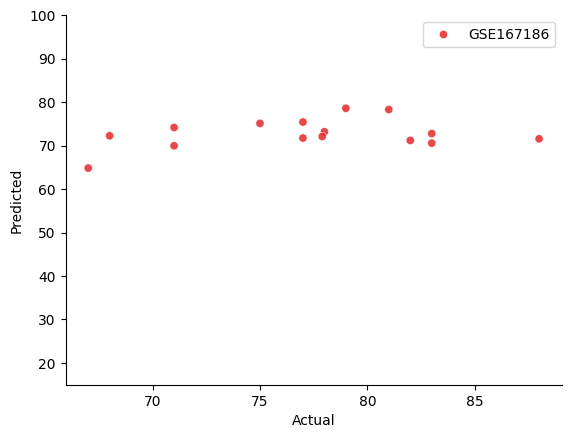

In [93]:
m.output_directory = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/Catboost"
m.plot_results(results=seq_results, labels=seq_z_test, save=True, save_output=f"catboost_regression_smote_sarcopenic_nonSarcopenia_{testing_size}.png")